In [ ]:
from pathlib import Path
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
import numpy as np
from coco_crop_dataset import CocoCropDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

%load_ext tensorboard

In [2]:
RESULTS_ROOT = Path("Individual Results")
GROUP_RESULTS_ROOT = Path("Group Results")

MODEL_NAME = "ResNet18_ViewingAngle"
OUT_DIR = RESULTS_ROOT / MODEL_NAME
SAVE_PATH = OUT_DIR / "resnet18_viewing_angle_best.pt"
HISTORY_PATH = OUT_DIR / "training_history.csv"

# Create all required directories
for d in [GROUP_RESULTS_ROOT, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- DATASET ROOT ----
COCO_ROOT = Path("CS2 Dataset/COCO-based_COCO_view_angle")

TRAIN_JSON = COCO_ROOT / "annotations/train.json"
VAL_JSON   = COCO_ROOT / "annotations/val.json"
TEST_JSON  = COCO_ROOT / "annotations/test.json"

TRAIN_IMG_DIR = COCO_ROOT / "images/train"
VAL_IMG_DIR   = COCO_ROOT / "images/val"
TEST_IMG_DIR  = COCO_ROOT / "images/test"

# ---- TRAINING PARAMS ----
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-3
NUM_WORKERS = 2

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", DEVICE)


Using device: mps


In [3]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])


train_ds = CocoCropDataset(TRAIN_JSON, TRAIN_IMG_DIR, train_tf)
val_ds   = CocoCropDataset(VAL_JSON,   VAL_IMG_DIR,   eval_tf)
test_ds  = CocoCropDataset(TEST_JSON,  TEST_IMG_DIR,  eval_tf)

print("Classes:", train_ds.class_names)
print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Classes: ['Back', 'Front', 'Side']
Train: 533 Val: 116 Test: 121


In [4]:
num_classes = len(train_ds.class_names)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [5]:
def run_epoch(loader, model, train=False):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


Epoch 01/25 | Train acc 0.735 | Val acc 0.328
Epoch 02/25 | Train acc 0.769 | Val acc 0.793
Epoch 03/25 | Train acc 0.820 | Val acc 0.716
Epoch 04/25 | Train acc 0.850 | Val acc 0.819
Epoch 05/25 | Train acc 0.895 | Val acc 0.819
Epoch 06/25 | Train acc 0.880 | Val acc 0.810
Epoch 07/25 | Train acc 0.872 | Val acc 0.793
Epoch 08/25 | Train acc 0.899 | Val acc 0.871
Epoch 09/25 | Train acc 0.897 | Val acc 0.776
Epoch 10/25 | Train acc 0.919 | Val acc 0.793
Epoch 11/25 | Train acc 0.921 | Val acc 0.845
Epoch 12/25 | Train acc 0.904 | Val acc 0.828
Epoch 13/25 | Train acc 0.916 | Val acc 0.776
Epoch 14/25 | Train acc 0.938 | Val acc 0.836
Epoch 15/25 | Train acc 0.929 | Val acc 0.836
Epoch 16/25 | Train acc 0.914 | Val acc 0.784
Epoch 17/25 | Train acc 0.925 | Val acc 0.836
Epoch 18/25 | Train acc 0.901 | Val acc 0.836
Epoch 19/25 | Train acc 0.916 | Val acc 0.819
Epoch 20/25 | Train acc 0.934 | Val acc 0.828
Epoch 21/25 | Train acc 0.927 | Val acc 0.819
Epoch 22/25 | Train acc 0.957 | Va

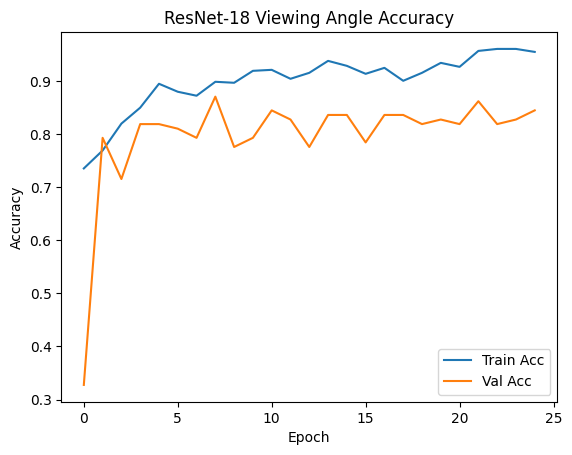

In [6]:
best_val_acc = 0.0
history = {"epoch":[],"train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, train=True)
    va_loss, va_acc = run_epoch(val_loader, model, train=False)

    history["epoch"].append(epoch)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train acc {tr_acc:.3f} | Val acc {va_acc:.3f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "model_state": model.state_dict(),
            "class_names": train_ds.class_names,
            "best_val_acc": best_val_acc
        }, SAVE_PATH)

print("Best validation accuracy:", best_val_acc)

df = pd.DataFrame(history)
df.to_csv(HISTORY_PATH, index=False)
print("Saved training history to resnet18_viewing_angle_history.csv")

plt.figure()
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet-18 Viewing Angle Accuracy")
plt.legend()
plt.show()

,Model,Accuracy
0,ResNet18_ViewingAngle,0.826446


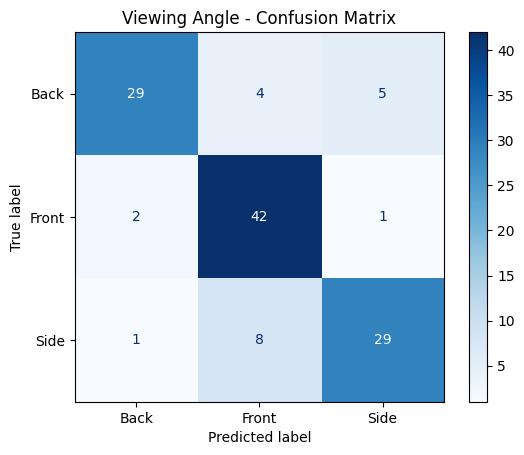

              precision    recall  f1-score   support

        Back      0.906     0.763     0.829        38
       Front      0.778     0.933     0.848        45
        Side      0.829     0.763     0.795        38

    accuracy                          0.826       121
   macro avg      0.838     0.820     0.824       121
weighted avg      0.834     0.826     0.825       121



In [7]:
ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
results_dict = {
    "Model": MODEL_NAME,
    "Accuracy": test_acc,
}
df = pd.DataFrame([results_dict])
csv_path = GROUP_RESULTS_ROOT / f"{MODEL_NAME}.csv"
df.to_csv(csv_path, index=False)
display(df)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=ckpt["class_names"])
disp.plot(cmap="Blues")
plt.title("Viewing Angle - Confusion Matrix")
plt.show()

print(classification_report(
    all_labels,
    all_preds,
    target_names=ckpt["class_names"],
    digits=3
))

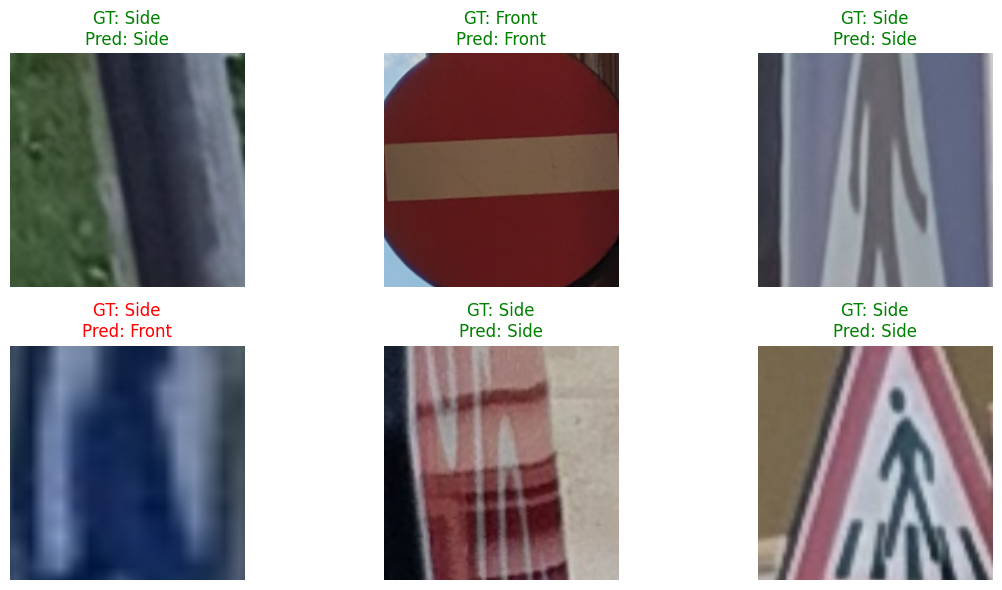

In [8]:
model.eval()

indices = random.sample(range(len(test_ds)), 6)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    img, gt = test_ds[idx]
    x = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(x).argmax(1).item()

    # Choose colour based on correctness
    title_color = "green" if gt == pred else "red"

    plt.subplot(2, 3, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(
        f"GT: {train_ds.class_names[gt]}\nPred: {train_ds.class_names[pred]}",
        color=title_color
    )
    plt.axis("off")

plt.tight_layout()
plt.show()